<a href="https://colab.research.google.com/github/mp371366/ML/blob/main/LAB02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 02

## GMM EM

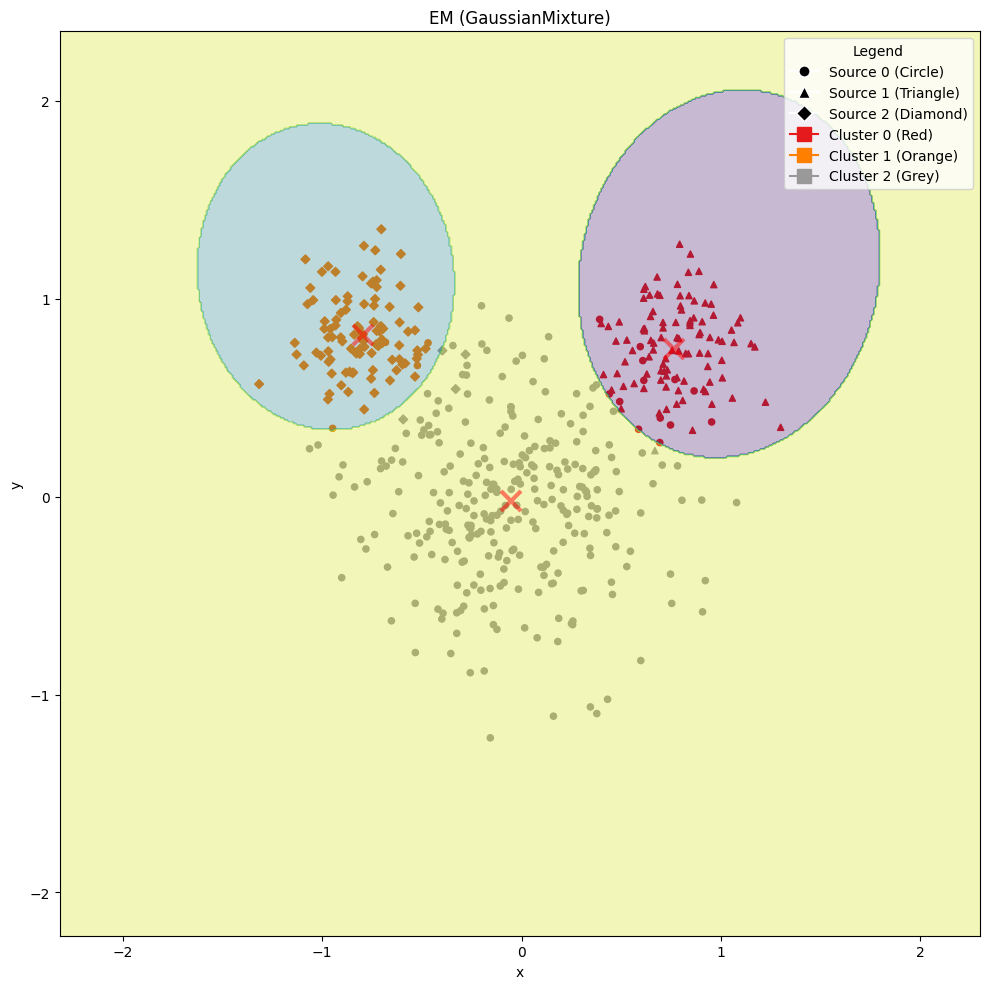

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ----------------------------------------------------------------------
# SECTION 1: Define a helper function to fit model
# ----------------------------------------------------------------------
def fit(model_class, X, n_runs=5, **kwargs):
    """
    Instantiates and fits `model_class(**kwargs)` on X `n_runs` times.
    Returns average runtime across those runs (in seconds).
    """
    for _ in range(n_runs):
        model = model_class(**kwargs)
        model.fit(X)
    return model

# ----------------------------------------------------------------------
# SECTION 2: Generate the "mouse" dataset
# ----------------------------------------------------------------------
np.random.seed(0)  # for reproducibility

# 1) 300 points from N([0, 0], [[0.16, 0],[0, 0.16]])
mean1 = np.array([0.0, 0.0])
cov1 = np.array([[0.16, 0.0],
                 [0.0,  0.16]])
data1 = np.random.multivariate_normal(mean1, cov1, 300)

# 2) 100 points from N([0.8, 0.8], [[0.04, 0],[0, 0.04]])
mean2 = np.array([0.8, 0.8])
cov2 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data2 = np.random.multivariate_normal(mean2, cov2, 100)

# 3) 100 points from N([-0.8, 0.8], [[0.04, 0],[0, 0.04]])
mean3 = np.array([-0.8, 0.8])
cov3 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data3 = np.random.multivariate_normal(mean3, cov3, 100)

# Combine all data
X = np.vstack([data1, data2, data3])
N, d = X.shape  # should be (500, 2)

# ----------------------------------------------------------------------
# SECTION 3: Measure runtime for each algorithm + final fit for plotting
# ----------------------------------------------------------------------
n_runs = 5  # number of runs to average the runtime

# EM for Gaussian Mixtures
gm_model = fit(
   GaussianMixture,
   X,
   n_runs=n_runs,
   n_components=3,
   covariance_type='full',
   random_state=42,
)
gm_labels = gm_model.predict(X)

# ----------------------------------------------------------------------
# SECTION 4: Plot clustering's results
# ----------------------------------------------------------------------

fig, axes = plt.subplots(1, 1, figsize=(10, 10))
data_counts = [300, 100, 100]  # Number of points per source
markers = ['o', '^', 'D']  # Circle, Triangle, Diamond

# Define markers for each data source
markers = ['o', '^', 'D']  # Circle, Triangle, Diamond
data_counts = [300, 100, 100]
# Create a normalizer to scale cluster labels to colormap range
norm = Normalize(vmin=0, vmax=2)  # Normalize colors between 0 and 2

start = 0
# EM (GaussianMixture)
for original_group in range(3):
  end = start + data_counts[original_group]
  axes.scatter(X[start:end,0], X[start:end,1], c=gm_labels[start:end], marker=markers[original_group], cmap='Set1', s=20, norm=norm)
  start = end

axes.plot(gm_model.means_[:, 0], gm_model.means_[:, 1], 'rx', markersize=14, mew=3, alpha=0.5)
axes.set_title("EM (GaussianMixture)")
axes.set_xlabel("x")
axes.set_ylabel("y")

# create grid
x = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 500)
y = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 500)
xx, yy = np.meshgrid(x, y)

grid = np.c_[xx.ravel(), yy.ravel()]

# predict region labels
Z = gm_model.predict(grid)
Z = Z.reshape(xx.shape)

# plot regions
plt.contourf(xx, yy, Z, alpha=0.3)

legend_elements = [
    # Markers for original data sources
    Line2D([0], [0], marker='o', color='w', markerfacecolor='k', markersize=8, label='Source 0 (Circle)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='k', markersize=8, label='Source 1 (Triangle)'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='k', markersize=8, label='Source 2 (Diamond)'),

    # Colors for inferred clusters
    Line2D([0], [0], marker='s', color=plt.cm.Set1(0.0), markersize=10, label='Cluster 0 (Red)'),
    Line2D([0], [0], marker='s', color=plt.cm.Set1(0.5), markersize=10, label='Cluster 1 (Orange)'),
    Line2D([0], [0], marker='s', color=plt.cm.Set1(1.0), markersize=10, label='Cluster 2 (Grey)')
]

# Add legend to the plot
axes.legend(handles=legend_elements, loc='best', frameon=True, title="Legend")

plt.tight_layout()
plt.show()

## Metrics

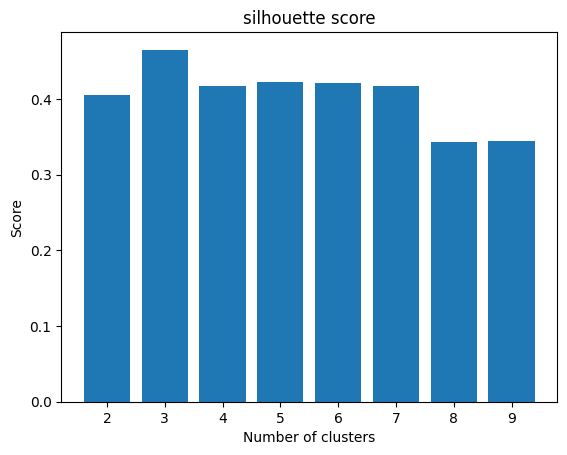

In [2]:
from sklearn.metrics import silhouette_score

## silhouette score
def ss(K):
    gm_model = fit(
        GaussianMixture,
        X,
        n_runs=n_runs,
        n_components=K,
        covariance_type='full',
        random_state=42,
    )
    gm_labels = gm_model.predict(X)

    return silhouette_score(X, gm_labels)

x = np.array(range(2, 10))
y = np.array([ ss(K) for K in x ])

plt.bar(x, y)
plt.xlabel("Number of clusters")
plt.ylabel("Score")
plt.title("silhouette score")
plt.show()


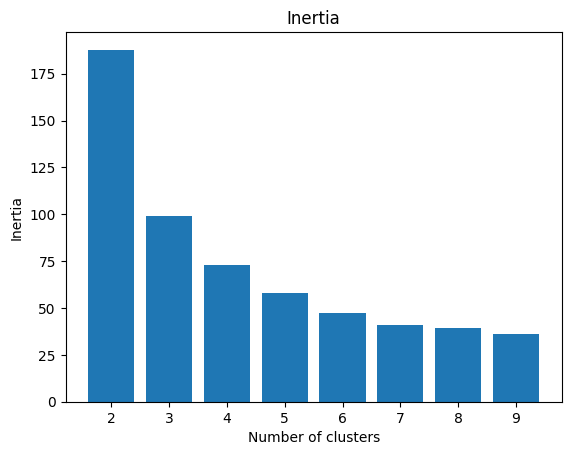

In [3]:
## inertia
def inertia(K):
    gm_model = fit(
        GaussianMixture,
        X,
        n_runs=n_runs,
        n_components=K,
        covariance_type='full',
        random_state=42,
    )
    gm_labels = gm_model.predict(X)

    inertia = 0
    for k in range(gm_model.n_components):
        cluster_points = X[gm_labels == k]
        inertia += np.sum((cluster_points - gm_model.means_[k])**2)

    return inertia

x = np.array(range(2, 10))
y = np.array([ inertia(K) for K in x ])

plt.bar(x, y)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Inertia")
plt.show()


We see that from 2 to 3 cluster the loss of inertia is big relative and absolutely. The other changes are much lower in both meanings.